# Lineare Regression – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/lineare-regression)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 19.01.2026

Die **lineare Regression** modelliert den Zusammenhang zwischen einer metrischen AV
und einer oder mehreren UV mit einer Geraden (OLS = Ordinary Least Squares).

**Regressionsgleichung:**
$$\hat{y} = a + b_1 x_1 + b_2 x_2 + \ldots + b_k x_k$$

| Symbol | Bedeutung |
|---|---|
| $\hat{y}$ | Vorhergesagter Wert der AV |
| $a$ | Achsenabschnitt (Intercept) |
| $b_i$ | Regressionskoeffizient (unstandardisiert) |
| $\beta_i$ | Standardisierter Koeffizient (messgrößenunabhängig, −1 bis +1) |

**Gütemasse:**
$$R^2 = \frac{\text{erklärte Varianz}}{\text{Gesamtvarianz}}, \qquad R^2_{adj} = 1 - (1-R^2)\frac{n-1}{n-k-1}$$

**Voraussetzungen:**
1. **Linearität** – linearer Zusammenhang X–Y
2. **Homoskedastizität** – konstante Residualvarianz
3. **Normalverteilung der Residuen**
4. **Keine Multikollinearität** (bei multipler Regression)
5. **Keine Autokorrelation** der Residuen

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro
import statsmodels.api as sm
import statsmodels.formula.api as smf

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Gewicht vorhersagen

**AV:** Gewicht (kg) | **UV:** Körpergröße (m), Alter, Geschlecht

**Datensatz (n = 10):**

| Gewicht | Größe | Alter | Geschlecht |
|---|---|---|---|
| 79 | 1,80 | 35 | männlich |
| 69 | 1,68 | 39 | männlich |
| 73 | 1,82 | 25 | männlich |
| 95 | 1,70 | 60 | männlich |
| 82 | 1,87 | 27 | männlich |
| 55 | 1,55 | 18 | weiblich |
| 69 | 1,50 | 89 | weiblich |
| 71 | 1,78 | 42 | weiblich |
| 64 | 1,67 | 16 | weiblich |
| 69 | 1,64 | 52 | weiblich |

**Erwartete numiqo-Ergebnisse:**
- R² = 0,754 (75,4 % Varianzaufklärung)
- Standardschätzfehler = 6,587
- Gewicht = 47,379·Größe + 0,297·Alter + 8,922·ist_männlich − 24,41
- Nur Alter signifikant (p < 0,05)

In [2]:
# numiqo-Datensatz
df = pd.DataFrame({
    "gewicht": [79, 69, 73, 95, 82, 55, 69, 71, 64, 69],
    "größe": [1.80, 1.68, 1.82, 1.70, 1.87, 1.55, 1.50, 1.78, 1.67, 1.64],
    "alter":   [35, 39, 25, 60, 27, 18, 89, 42, 16, 52],
    "geschlecht": ["m","m","m","m","m","w","w","w","w","w"]
})
df["ist_männlich"] = (df["geschlecht"] == "m").astype(float)

# Multiple lineare Regression
model = smf.ols("gewicht ~ größe + alter + ist_männlich", data=df).fit()

print("Multiple Lineare Regression: Gewicht")
print()
print("R2          = " + str(round(model.rsquared, 4)) + "  (numiqo: 0.754)")
print("R2 adj.     = " + str(round(model.rsquared_adj, 4)))
print("Std.fehler  = " + str(round(model.mse_resid**0.5, 4)) + "  (numiqo: 6.587)")
print("F-Statistik = " + str(round(model.fvalue, 4)) +
      "  p=" + str(round(model.f_pvalue, 4)))
print()
print("Regressionskoeffizienten:")
print("Koeffizient       b        SE       t       p")
for name, b, se, t_v, p_v in zip(
    model.params.index,
    model.params.values,
    model.bse.values,
    model.tvalues.values,
    model.pvalues.values
):
    sig = "*" if p_v < 0.05 else ""
    print(name + "  " + str(round(b,3)) + "  " + str(round(se,3)) +
          "  " + str(round(t_v,3)) + "  " + str(round(p_v,4)) + " " + sig)
print()
print("Regressionsgleichung (numiqo):")
b = model.params
print("Gewicht = " + str(round(b.iloc[1],3)) + "*Größe + " +
      str(round(b.iloc[2],3)) + "*Alter + " +
      str(round(b.iloc[3],3)) + "*ist_männlich + " +
      str(round(b.iloc[0],3)))
print("Referenz numiqo: 47.379*Größe + 0.297*Alter + 8.922*ist_männlich - 24.41")

Multiple Lineare Regression: Gewicht

R2          = 0.7535  (numiqo: 0.754)
R2 adj.     = 0.6303
Std.fehler  = 6.5873  (numiqo: 6.587)
F-Statistik = 6.1151  p=0.0296

Regressionskoeffizienten:
Koeffizient       b        SE       t       p
Intercept  -24.41  47.641  -0.512  0.6267 
größe  47.379  27.628  1.715  0.1372 
alter  0.297  0.114  2.602  0.0406 *
ist_männlich  8.922  5.603  1.592  0.1624 

Regressionsgleichung (numiqo):
Gewicht = 47.379*Größe + 0.297*Alter + 8.922*ist_männlich + -24.41
Referenz numiqo: 47.379*Größe + 0.297*Alter + 8.922*ist_männlich - 24.41


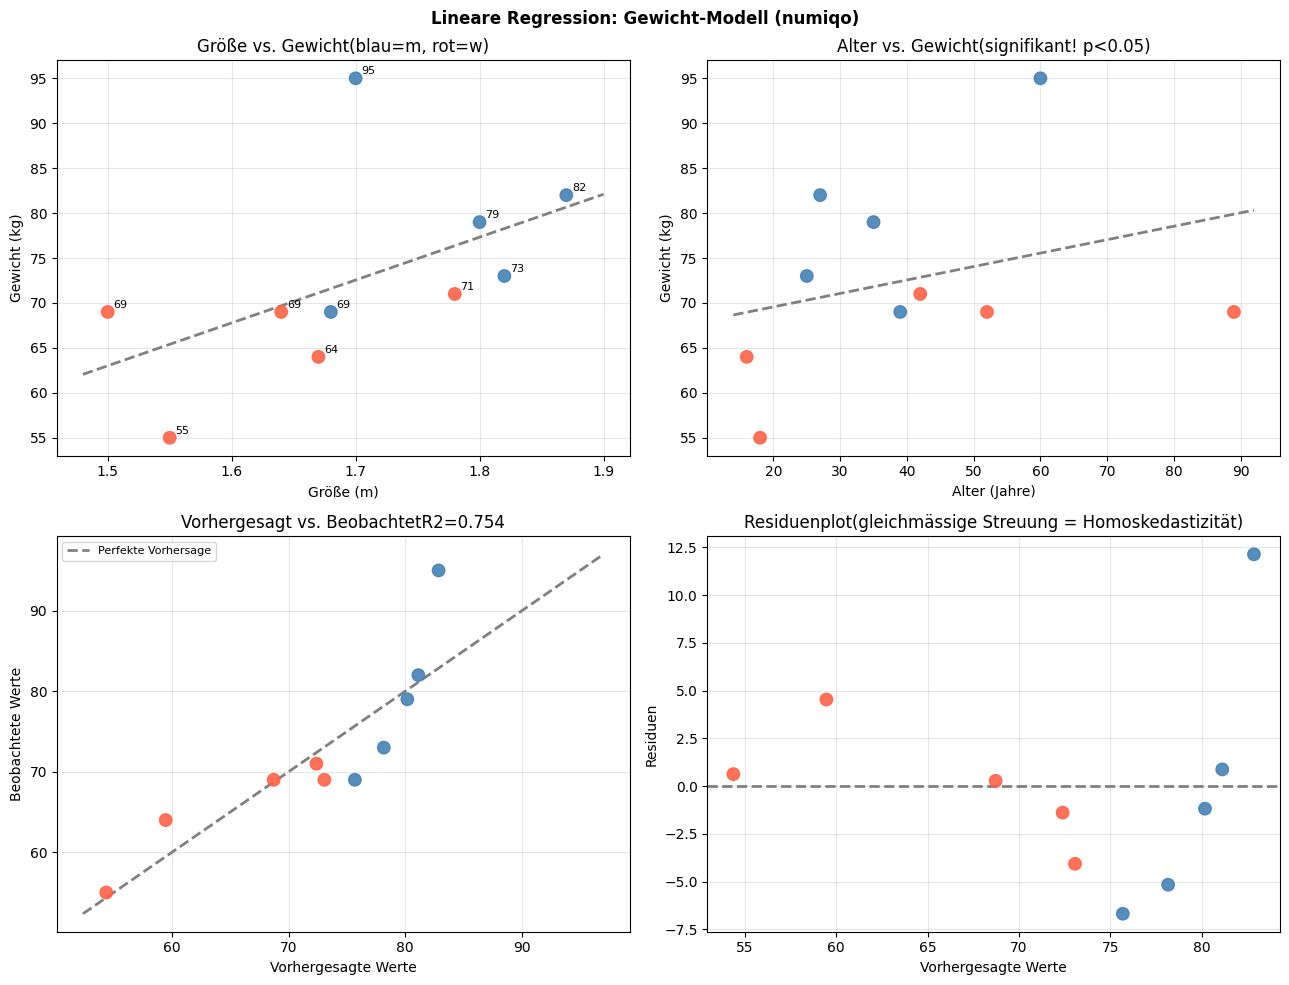

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Lineare Regression: Gewicht-Modell (numiqo)",
             fontsize=12, fontweight="bold")

farben_g = {"m": "steelblue", "w": "tomato"}
fc_list  = [farben_g[g] for g in df["geschlecht"]]

# 1. Streudiagramm Größe vs. Gewicht
axes[0,0].scatter(df["größe"], df["gewicht"], c=fc_list, s=80, alpha=0.9, zorder=3)
m_g, b_g = np.polyfit(df["größe"], df["gewicht"], 1)
x_g = np.linspace(1.48, 1.90, 100)
axes[0,0].plot(x_g, m_g*x_g+b_g, color="gray", linewidth=2, linestyle="--")
for _, row in df.iterrows():
    axes[0,0].annotate(str(int(row["gewicht"])),
                       (row["größe"], row["gewicht"]),
                       textcoords="offset points", xytext=(4, 3), fontsize=8)
axes[0,0].set_title("Größe vs. Gewicht(blau=m, rot=w)")
axes[0,0].set_xlabel("Größe (m)")
axes[0,0].set_ylabel("Gewicht (kg)")
axes[0,0].grid(alpha=0.3)

# 2. Alter vs. Gewicht
axes[0,1].scatter(df["alter"], df["gewicht"], c=fc_list, s=80, alpha=0.9, zorder=3)
m_a, b_a = np.polyfit(df["alter"], df["gewicht"], 1)
x_a = np.linspace(14, 92, 100)
axes[0,1].plot(x_a, m_a*x_a+b_a, color="gray", linewidth=2, linestyle="--")
axes[0,1].set_title("Alter vs. Gewicht(signifikant! p<0.05)")
axes[0,1].set_xlabel("Alter (Jahre)")
axes[0,1].set_ylabel("Gewicht (kg)")
axes[0,1].grid(alpha=0.3)

# 3. Vorhergesagt vs. Beobachtet
y_pred = model.fittedvalues
axes[1,0].scatter(y_pred, df["gewicht"], c=fc_list, s=80, alpha=0.9, zorder=3)
min_v = min(y_pred.min(), df["gewicht"].min()) - 2
max_v = max(y_pred.max(), df["gewicht"].max()) + 2
axes[1,0].plot([min_v, max_v], [min_v, max_v], color="gray",
               linestyle="--", linewidth=2, label="Perfekte Vorhersage")
axes[1,0].set_title("Vorhergesagt vs. BeobachtetR2=" + str(round(model.rsquared, 3)))
axes[1,0].set_xlabel("Vorhergesagte Werte")
axes[1,0].set_ylabel("Beobachtete Werte")
axes[1,0].legend(fontsize=8)
axes[1,0].grid(alpha=0.3)

# 4. Residuenplot (Homoskedastiziät)
residuen = model.resid
axes[1,1].scatter(y_pred, residuen, c=fc_list, s=80, alpha=0.9, zorder=3)
axes[1,1].axhline(0, color="gray", linestyle="--", linewidth=2)
axes[1,1].set_title("Residuenplot(gleichmässige Streuung = Homoskedastizität)")
axes[1,1].set_xlabel("Vorhergesagte Werte")
axes[1,1].set_ylabel("Residuen")
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Methode der kleinsten Quadrate (OLS)

OLS minimiert die **Summe der quadrierten Residuen** $\sum e_i^2 = \sum (y_i - \hat{y}_i)^2$.

Die analytische Lösung für die einfache Regression:
$$b = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}, \qquad a = \bar{y} - b\bar{x}$$

OLS manuell: Alter -> Gewicht

x_bar = 40.3
y_bar = 72.6
b = 0.1495  (Gewichtszunahme pro Jahr)
a = 66.5733

Regressionsgleichung: Gewicht = 66.57 + 0.15 * Alter

Vorhersagen:
  Alter=35 Gewicht=79 Vorhergesagt=71.8 Residuum=7.2
  Alter=39 Gewicht=69 Vorhergesagt=72.4 Residuum=-3.4
  Alter=25 Gewicht=73 Vorhergesagt=70.3 Residuum=2.7
  Alter=60 Gewicht=95 Vorhergesagt=75.5 Residuum=19.5
  Alter=27 Gewicht=82 Vorhergesagt=70.6 Residuum=11.4
  Alter=18 Gewicht=55 Vorhergesagt=69.3 Residuum=-14.3
  Alter=89 Gewicht=69 Vorhergesagt=79.9 Residuum=-10.9
  Alter=42 Gewicht=71 Vorhergesagt=72.9 Residuum=-1.9
  Alter=16 Gewicht=64 Vorhergesagt=69.0 Residuum=-5.0
  Alter=52 Gewicht=69 Vorhergesagt=74.3 Residuum=-5.3

SSE (Summe quad. Residuen) = 957.37
R2 = 0.0937


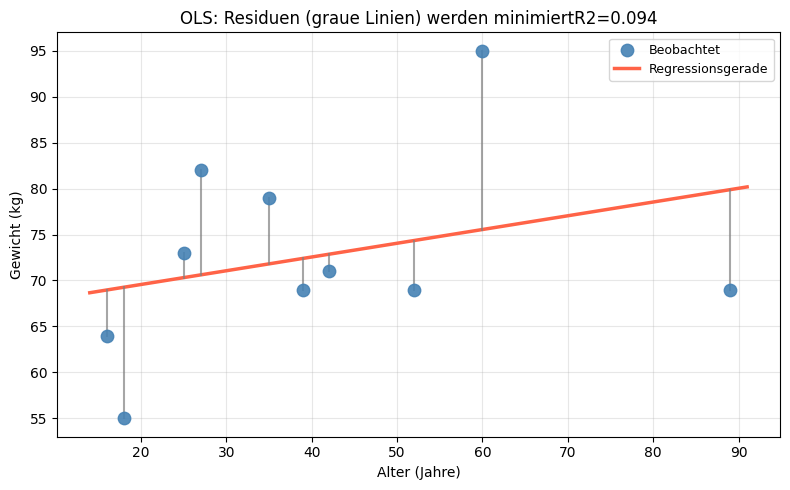

In [4]:
# OLS manuell fuer einfache Regression (Alter -> Gewicht)
x_ols = df["alter"].values.astype(float)
y_ols = df["gewicht"].values.astype(float)

x_bar = x_ols.mean()
y_bar = y_ols.mean()

b_ols = ((x_ols - x_bar) * (y_ols - y_bar)).sum() / ((x_ols - x_bar)**2).sum()
a_ols = y_bar - b_ols * x_bar
y_hat = a_ols + b_ols * x_ols
residuen_ols = y_ols - y_hat
sse = (residuen_ols**2).sum()
sst = ((y_ols - y_bar)**2).sum()
r2_ols = 1 - sse/sst

print("OLS manuell: Alter -> Gewicht")
print()
print("x_bar = " + str(round(x_bar, 2)))
print("y_bar = " + str(round(y_bar, 2)))
print("b = " + str(round(b_ols, 4)) + "  (Gewichtszunahme pro Jahr)")
print("a = " + str(round(a_ols, 4)))
print()
print("Regressionsgleichung: Gewicht = " + str(round(a_ols, 2)) +
      " + " + str(round(b_ols, 3)) + " * Alter")
print()
print("Vorhersagen:")
for i, (alter_i, y_i, yh_i, e_i) in enumerate(zip(x_ols, y_ols, y_hat, residuen_ols)):
    print("  Alter=" + str(int(alter_i)) + " Gewicht=" + str(int(y_i)) +
          " Vorhergesagt=" + str(round(yh_i, 1)) +
          " Residuum=" + str(round(e_i, 1)))
print()
print("SSE (Summe quad. Residuen) = " + str(round(sse, 2)))
print("R2 = " + str(round(r2_ols, 4)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_ols, y_ols, color="steelblue", s=80, alpha=0.9, zorder=3, label="Beobachtet")
x_line = np.linspace(x_ols.min()-2, x_ols.max()+2, 100)
ax.plot(x_line, a_ols + b_ols*x_line, color="tomato", linewidth=2.5, label="Regressionsgerade")
for xi, yi, yhi in zip(x_ols, y_ols, y_hat):
    ax.plot([xi, xi], [yi, yhi], color="gray", linewidth=1.5, alpha=0.7)
ax.set_title("OLS: Residuen (graue Linien) werden minimiertR2=" + str(round(r2_ols,3)))
ax.set_xlabel("Alter (Jahre)")
ax.set_ylabel("Gewicht (kg)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Voraussetzungen prüfen

Alle fünf Voraussetzungen werden auf dem numiqo-Datensatz geprüft.

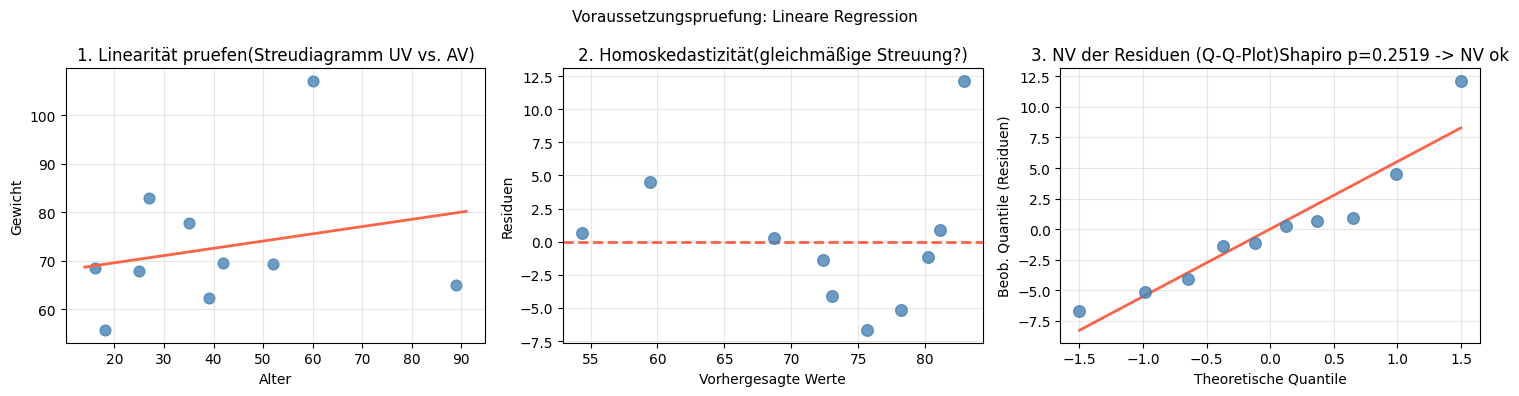

Multikollinearität: VIF
VIF < 5: keine Multikollinearität
größe: VIF=2.24 -> OK
alter: VIF=1.33 -> OK
ist_männlich: VIF=1.81 -> OK


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Voraussetzungspruefung: Lineare Regression", fontsize=11)

res = model.resid
y_fit = model.fittedvalues

# 1. Linearität: Partielle Regressionsplots (Alter als Hauptprädiktor)
axes[0].scatter(df["alter"], res + df["gewicht"], color="steelblue", s=60, alpha=0.8)
m_lin, b_lin = np.polyfit(df["alter"], df["gewicht"], 1)
x_lin = np.linspace(df["alter"].min()-2, df["alter"].max()+2, 100)
axes[0].plot(x_lin, m_lin*x_lin+b_lin, color="tomato", linewidth=2)
axes[0].set_title("1. Linearität pruefen(Streudiagramm UV vs. AV)")
axes[0].set_xlabel("Alter")
axes[0].set_ylabel("Gewicht")
axes[0].grid(alpha=0.3)

# 2. Homoskedastizität
axes[1].scatter(y_fit, res, color="steelblue", s=70, alpha=0.8, zorder=3)
axes[1].axhline(0, color="tomato", linestyle="--", linewidth=2)
axes[1].set_title("2. Homoskedastizität(gleichmäßige Streuung?)")
axes[1].set_xlabel("Vorhergesagte Werte")
axes[1].set_ylabel("Residuen")
axes[1].grid(alpha=0.3)

# 3. NV der Residuen (Q-Q-Plot)
(osm, osr), (slope, intercept, _) = stats.probplot(res, dist="norm")
axes[2].scatter(osm, osr, color="steelblue", s=70, alpha=0.8, zorder=3)
axes[2].plot(osm, slope*osm+intercept, color="tomato", linewidth=2)
w_sw, p_sw = shapiro(res)
axes[2].set_title("3. NV der Residuen (Q-Q-Plot)Shapiro p=" +
                  str(round(p_sw, 4)) +
                  " -> " + ("NV ok" if p_sw > 0.05 else "NV verletzt"))
axes[2].set_xlabel("Theoretische Quantile")
axes[2].set_ylabel("Beob. Quantile (Residuen)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Multikollinearität (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = sm.add_constant(df[["größe", "alter", "ist_männlich"]])
print("Multikollinearität: VIF")
print("VIF < 5: keine Multikollinearität")
for i, col in enumerate(["größe", "alter", "ist_männlich"]):
    vif = variance_inflation_factor(X_vif.values, i+1)
    interp = "OK" if vif < 5 else ("mittel" if vif < 10 else "PROBLEM!")
    print(col + ": VIF=" + str(round(vif, 2)) + " -> " + interp)

In [6]:
# Vorhersage mit dem Modell
print("Vorhersage: neue Personen")
print()
neue_personen = pd.DataFrame({
    "größe": [1.75, 1.65, 1.90],
    "alter":   [30,   45,   22],
    "ist_männlich": [1.0, 0.0, 1.0]
})

vorhersagen = model.predict(neue_personen)
print("Größe  Alter  Geschlecht  Vorhergesagtes Gewicht")
for i, (_, row) in enumerate(neue_personen.iterrows()):
    g = "m" if row["ist_männlich"] == 1 else "w"
    print(str(row["größe"]) + "   " + str(int(row["alter"])) +
          "     " + g + "           " + str(round(vorhersagen.iloc[i], 1)) + " kg")

Vorhersage: neue Personen

Größe  Alter  Geschlecht  Vorhergesagtes Gewicht
1.75   30     m           76.3 kg
1.65   45     w           67.1 kg
1.9   22     m           81.1 kg


In [7]:
# APA-Ausgabe-Funktion
def linreg_apa(model_obj, abh_var="AV", alpha=0.05):
    print("Lineare Regression: " + abh_var)
    print("n=" + str(int(model_obj.nobs)))
    print()
    print("Modellguete:")
    print("  R2=" + str(round(model_obj.rsquared, 4)) +
          "  R2_adj=" + str(round(model_obj.rsquared_adj, 4)) +
          "  RMSE=" + str(round(model_obj.mse_resid**0.5, 4)))
    print("  F(" + str(int(model_obj.df_model)) + "," +
          str(int(model_obj.df_resid)) + ")=" +
          str(round(model_obj.fvalue, 3)) +
          "  p=" + str(round(model_obj.f_pvalue, 4)))
    print()
    print("Koeffizienten:")
    print("Variable          b       SE      t       p       sig")
    for name in model_obj.params.index:
        b_v  = model_obj.params[name]
        se_v = model_obj.bse[name]
        t_v  = model_obj.tvalues[name]
        p_v  = model_obj.pvalues[name]
        sig  = "***" if p_v<0.001 else ("**" if p_v<0.01 else ("*" if p_v<0.05 else "n.s."))
        print(name + "  " + str(round(b_v,3)) + "  " + str(round(se_v,3)) +
              "  " + str(round(t_v,3)) + "  " + str(round(p_v,4)) + "  " + sig)
    print()

linreg_apa(model, "Gewicht (kg)")

Lineare Regression: Gewicht (kg)
n=10

Modellguete:
  R2=0.7535  R2_adj=0.6303  RMSE=6.5873
  F(3,6)=6.115  p=0.0296

Koeffizienten:
Variable          b       SE      t       p       sig
Intercept  -24.41  47.641  -0.512  0.6267  n.s.
größe  47.379  27.628  1.715  0.1372  n.s.
alter  0.297  0.114  2.602  0.0406  *
ist_männlich  8.922  5.603  1.592  0.1624  n.s.



## 4. Zusammenfassung

```
Lineare Regression – Übersicht
│
├── FORMEN
│   Einfach:  1 UV  -> y = a + b*x
│   Multiple: k UV  -> y = a + b1*x1 + ... + bk*xk
│
├── OLS (Methode der kleinsten Quadrate)
│   Minimiert: Sum(yi - y_hat_i)^2
│   b = Cov(X,Y) / Var(X)
│   a = y_bar - b * x_bar
│
├── GUTEMASSE
│   R2:     Anteil erklärter Varianz (0-1, höher = besser)
│   R2_adj: Bereinigt um Anzahl UV (bei multipler Reg. verwenden)
│   RMSE:   Mittlerer Vorhersagefehler (in Einheit der AV)
│
├── SIGNIFIKANZTESTS
│   F-Test: Ist das Gesamtmodell signifikant?
│   t-Test: Ist jeder Koeffizient signifikant von 0 verschieden?
│
├── VORAUSSETZUNGEN
│   Linearität:        Streudiagramm pruefen
│   Homoskedastizität: Residuenplot pruefen
│   NV der Residuen:    Q-Q-Plot / Shapiro-Wilk
│   Keine Multikollinearität: VIF < 5 (bei mult. Regression)
│   Keine Autokorrelation: Durbin-Watson-Test
│
├── KOEFFIZIENTEN
│   b (unstandardisiert): Einheit der Variable beachten!
│   Beta (standardisiert): vergleichbar, -1 bis +1
│   Interpretation: Bei Zunahme von x um 1 Einheit
│                   ändert sich y um b Einheiten
│
├── numiqo-BEISPIEL: Gewicht (n=10)
│   R2=0.754, Std.fehler=6.587
│   Gewicht = 47.38*Größe + 0.297*Alter + 8.922*ist_m - 24.41
│   Nur Alter signifikant (p<0.05)
│
└── PYTHON
    import statsmodels.formula.api as smf
    model = smf.ols("y ~ x1 + x2", data=df).fit()
    print(model.summary())
```

---
Quelle: [numiqo.de/tutorial/lineare-regression](https://numiqo.de/tutorial/lineare-regression)